# Neuro-Symmetry v2 â€” Ultra Pro Full-Data Training (ALL Datasets)

Processes the **entire 648 K+ image corpus** through MediaPipe Face Mesh,
extracts 50-dim feature vectors, and trains a clinically-calibrated 3-class
classifier with Float16 export for edge deployment.

| Source | Label | Images |
|--------|-------|--------|
| CelebA aligned JPG (all 202,599) | 0 Normal | 202,599 |
| CelebA aligned PNG (all 202,599) | 0 Normal | 202,599 |
| CelebA wild JPG (all 202,599) | 0 Normal | 202,599 |
| AffectNet YOLO â€” ALL 8 classes (train+valid+test) | 0 Normal | ~25,262 |
| 300-W AFW | 0 Normal | 200 |
| YFP Mild + Moderate | 1 Mild | ~7,589 |
| YFP Mod-Severe + Severe | 2 Severe | ~6,800 |

> **AffectNet note:** All 8 expression classes (Anger, Contempt, Disgust, Fear,
> Happy, Neutral, Sad, Surprise) are healthy faces with no neurological palsy.
> They all map to label 0 (Normal). Using all classes adds expression-variation
> robustness so the model doesn't confuse normal expressions with pathology.

### What's new vs previous version
- **CelebA PNG** â€” 202,599 lossless images added (texture diversity)
- **AffectNet full** â€” all 25,262 images (was ~2,380 Neutral-only)
- **Grand total: ~648 K images** (was ~420 K)
- **SYNTH_EXTRA boosted to 3,000/class** to better balance the ~46:1 imbalance
- **TRAIN_EPOCHS = 120** (more data â†’ more training needed)

## 0. Configuration

In [16]:
from pathlib import Path

N_WORKERS    = 4
CHUNK_SIZE   = 2_000
TRAIN_EPOCHS = 120
BATCH_SIZE   = 512
LR           = 1e-3
SYNTH_EXTRA  = 15_000

QUICK_MODE = False
QUICK_CAP  = 300

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'ai').exists() and (PROJECT_ROOT.parent / 'ai').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

CACHE_DIR = PROJECT_ROOT / 'ai' / 'cache'
OUT_DIR   = PROJECT_ROOT / 'ai' / 'checkpoints'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Config  N_WORKERS={N_WORKERS}  SYNTH_EXTRA={SYNTH_EXTRA}  LR={LR}')
print(f'  ProjectRoot={PROJECT_ROOT}')


Config  N_WORKERS=4  SYNTH_EXTRA=15000  LR=0.001
  ProjectRoot=f:\Projects\Neuro-Symmetry\neuro-symmetry-v2


In [17]:
%pip install onnx onnxscript

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports

In [18]:
import io, sys, json, time, warnings, threading
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
warnings.filterwarnings('ignore')

if hasattr(sys.stdout, 'buffer') and sys.stdout.encoding.lower() != 'utf-8':
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8', errors='replace')
    sys.stderr = io.TextIOWrapper(sys.stderr.buffer, encoding='utf-8', errors='replace')

# Ensure local project modules (datasets/backend/ai) are importable from notebook
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'ai').exists() and (PROJECT_ROOT.parent / 'ai').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
from tqdm.auto import tqdm

from datasets.config import (
    CELEBA_IMGS_ALIGNED, CELEBA_IMGS_ALIGNED_PNG, CELEBA_IMGS_WILD, CELEBA_EVAL,
    W300_AFW, YFP_ROOT,
    YOLO_ROOT,
    )
from datasets.palsy_loader import _collect_samples
from backend.api.image_loader      import ImageLoader
from backend.api.landmark_engine   import LandmarkEngine
from backend.api.input_quality     import InputQualityChecker
from backend.api.feature_extractor import extract_features, N_FEATURES, FEATURE_NAMES

print('Imports OK')

Imports OK


In [19]:
from datasets.config import verify_paths
verify_paths()

# Report what's available
sources = {
    'CelebA aligned JPG':  CELEBA_IMGS_ALIGNED,
    'CelebA aligned PNG':  CELEBA_IMGS_ALIGNED_PNG,
    'CelebA wild JPG':     CELEBA_IMGS_WILD,
    'AffectNet YOLO':      YOLO_ROOT,
    '300-W AFW':           W300_AFW,
    'YFP Palsy':           YFP_ROOT,
}
for name, path in sources.items():
    status = 'âœ“' if path.exists() else 'âœ— MISSING'
    print(f'  {status}  {name:25s}  {path}')

  âœ“  CelebA aligned JPG         F:\Projects\Neuro-Symmetry\Datasets\Celeba\img\img_align_celeba
  âœ“  CelebA aligned PNG         F:\Projects\Neuro-Symmetry\Datasets\Celeba\img\img_align_celeba_png
  âœ“  CelebA wild JPG            F:\Projects\Neuro-Symmetry\Datasets\Celeba\img\img_celeba
  âœ“  AffectNet YOLO             F:\Projects\Neuro-Symmetry\Datasets\YOLO_format
  âœ“  300-W AFW                  F:\Projects\Neuro-Symmetry\Datasets\ibug_300W_large_face_landmark_dataset\afw
  âœ“  YFP Palsy                  F:\Projects\Neuro-Symmetry\Datasets\YFP_Dataset


In [20]:
_local = threading.local()

def _get_engine():
    if not hasattr(_local, 'engine'):
        _local.engine  = LandmarkEngine()
        _local.checker = InputQualityChecker()
    return _local.engine, _local.checker


def _process_one(img_path):
    """Thread-safe: load â†’ landmark â†’ quality gate â†’ features."""
    frame = ImageLoader.load(img_path)
    if frame is None:
        return None, 'read_error'
    engine, checker = _get_engine()
    result  = engine.process(frame)
    quality = checker.check(frame, result)
    if not quality.is_usable:
        return None, quality.reason or 'quality_rejected'
    return extract_features(result, frame), 'ok'


def extract_dataset(paths, labels, cache_path, desc='extracting'):
    """
    Extract features for every path with parallel threads + disk checkpointing.
    `labels`: int (single class) or list[int] (per-image).
    Returns (features float32, labels int64).
    """
    if cache_path.exists():
        d = np.load(cache_path)
        print(f'[{desc}] cache hit â†’ {d["features"].shape[0]:,} samples')
        return d['features'].astype(np.float32), d['labels'].astype(np.int64)

    scalar  = isinstance(labels, int)
    partial = cache_path.with_suffix('.partial.npz')
    done_f, done_l, start = [], [], 0

    if partial.exists():
        p = np.load(partial)
        done_f = list(p['features']); done_l = list(p['labels'])
        start  = int(p['processed'])
        print(f'[{desc}] resuming from {start:,}')

    remaining = paths[start:]
    if QUICK_MODE:
        remaining = remaining[:max(0, QUICK_CAP - start)]

    stats = {'ok': len(done_f), 'rejected': 0}

    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {pool.submit(_process_one, p): i for i, p in enumerate(remaining)}
        pbar    = tqdm(total=len(remaining), desc=desc)
        chunk   = 0
        for fut in as_completed(futures):
            i    = futures[fut]
            gi   = start + i
            feat, status = fut.result()
            if status == 'ok':
                done_f.append(feat)
                done_l.append(labels if scalar else labels[gi])
                stats['ok'] += 1
            else:
                stats['rejected'] += 1
            pbar.update(1); chunk += 1
            if chunk % CHUNK_SIZE == 0 and done_f:
                np.savez_compressed(
                    partial,
                    features=np.stack(done_f),
                    labels=np.array(done_l, dtype=np.int64),
                    processed=np.array(start + chunk),
                )
        pbar.close()

    feats = np.stack(done_f).astype(np.float32)
    lbls  = np.array(done_l, dtype=np.int64)
    np.savez_compressed(cache_path, features=feats, labels=lbls)
    if partial.exists(): partial.unlink()

    print(f'[{desc}] ok={stats["ok"]:,}  rejected={stats["rejected"]:,}')
    return feats, lbls


print('Extraction engine ready.')

Extraction engine ready.


In [21]:
part_lines = (CELEBA_EVAL / 'list_eval_partition.txt').read_text().splitlines()
celeba_aligned_jpg_paths = [CELEBA_IMGS_ALIGNED / ln.split()[0] for ln in part_lines]
print(f'CelebA aligned JPG: {len(celeba_aligned_jpg_paths):,} images')

feat_celeba_jpg, lbl_celeba_jpg = extract_dataset(
    celeba_aligned_jpg_paths, labels=0,
    cache_path=CACHE_DIR / 'celeba_aligned_normal.npz',
    desc='CelebA aligned JPG',
)

CelebA aligned JPG: 202,599 images
[CelebA aligned JPG] cache hit â†’ 196,341 samples


In [22]:
feat_celeba_png = lbl_celeba_png = None

if CELEBA_IMGS_ALIGNED_PNG.exists():
    celeba_aligned_png_paths = [CELEBA_IMGS_ALIGNED_PNG / ln.split()[0].replace('.jpg', '.png')
                                 for ln in part_lines]
    # Filter to only paths that actually exist (filename extension may vary)
    celeba_aligned_png_paths = [
        p if p.exists() else p.with_suffix('.jpg')
        for p in celeba_aligned_png_paths
    ]
    celeba_aligned_png_paths = [p for p in celeba_aligned_png_paths if p.exists()]
    print(f'CelebA aligned PNG: {len(celeba_aligned_png_paths):,} images found')

    feat_celeba_png, lbl_celeba_png = extract_dataset(
        celeba_aligned_png_paths, labels=0,
        cache_path=CACHE_DIR / 'celeba_aligned_png_normal.npz',
        desc='CelebA aligned PNG',
    )
else:
    print(f'CelebA aligned PNG not found at {CELEBA_IMGS_ALIGNED_PNG} â€” skipping.')

CelebA aligned PNG: 202,599 images found
[CelebA aligned PNG] cache hit â†’ 200,566 samples


In [23]:
feat_celeba_wild = lbl_celeba_wild = None

if CELEBA_IMGS_WILD.exists():
    celeba_wild_paths = [CELEBA_IMGS_WILD / ln.split()[0] for ln in part_lines]
    print(f'CelebA wild JPG: {len(celeba_wild_paths):,} images')
    feat_celeba_wild, lbl_celeba_wild = extract_dataset(
        celeba_wild_paths, labels=0,
        cache_path=CACHE_DIR / 'celeba_wild_normal.npz',
        desc='CelebA wild JPG',
    )
else:
    print(f'CelebA wild not found at {CELEBA_IMGS_WILD} â€” skipping.')

CelebA wild JPG: 202,599 images
[CelebA wild JPG] cache hit â†’ 185,370 samples


In [24]:
affectnet_paths = []
affectnet_class_counts = {}

for split in ('train', 'valid', 'test'):
    lbl_dir = YOLO_ROOT / split / 'labels'
    img_dir = YOLO_ROOT / split / 'images'
    if not lbl_dir.exists():
        print(f'  Split {split}: labels dir not found, skipping')
        continue
    for lf in sorted(lbl_dir.glob('*.txt')):
        txt = lf.read_text().strip()
        if not txt:
            continue
        cls_id = int(txt.split()[0])
        # ALL classes 0-7 are normal (no neurological palsy in AffectNet)
        found = ImageLoader.find(lf.stem, img_dir)
        if found:
            affectnet_paths.append(found)
            affectnet_class_counts[cls_id] = affectnet_class_counts.get(cls_id, 0) + 1

YOLO_CLASS_NAMES = ['Anger','Contempt','Disgust','Fear','Happy','Neutral','Sad','Surprise']
print(f'AffectNet ALL classes: {len(affectnet_paths):,} images total')
for cid, name in enumerate(YOLO_CLASS_NAMES):
    n = affectnet_class_counts.get(cid, 0)
    print(f'  [{cid}] {name:<12} {n:,}')

feat_affectnet, lbl_affectnet = extract_dataset(
    affectnet_paths, labels=0,
    cache_path=CACHE_DIR / 'affectnet_all_classes_normal.npz',
    desc='AffectNet all classes',
)

AffectNet ALL classes: 25,262 images total
  [0] Anger        3,434
  [1] Contempt     2,946
  [2] Disgust      3,241
  [3] Fear         2,961
  [4] Happy        3,344
  [5] Neutral      2,380
  [6] Sad          2,795
  [7] Surprise     4,161
[AffectNet all classes] cache hit â†’ 25,169 samples


In [25]:
w300_paths = ImageLoader.collect(W300_AFW)
# Filter to JPG only (exclude .pts landmark annotation files)
w300_paths = [p for p in w300_paths if p.suffix.lower() in ('.jpg', '.png', '.jpeg', '.bmp')]
print(f'300-W AFW: {len(w300_paths)} images')

feat_w300, lbl_w300 = extract_dataset(
    w300_paths, labels=0,
    cache_path=CACHE_DIR / 'w300_normal.npz',
    desc='300-W AFW',
)

300-W AFW: 200 images
[300-W AFW] cache hit â†’ 92 samples


In [26]:
yfp_samples = _collect_samples(YFP_ROOT, fine_grained=False)
yfp_paths   = [s[0] for s in yfp_samples]
yfp_labels  = [s[1] for s in yfp_samples]
print(f'YFP: {len(yfp_paths):,} total')
print(f'  Mild (1):   {yfp_labels.count(1):,}')
print(f'  Severe (2): {yfp_labels.count(2):,}')

feat_yfp, lbl_yfp = extract_dataset(
    yfp_paths, labels=yfp_labels,
    cache_path=CACHE_DIR / 'yfp_palsy_full.npz',
    desc='YFP palsy',
)

YFP: 14,389 total
  Mild (1):   7,589
  Severe (2): 6,800
[YFP palsy] cache hit â†’ 8,416 samples


In [27]:
from ai.synthetic_augment import build_dataset as build_synthetic

# â”€â”€ Collect ALL normal sources â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
normal_feats  = [feat_celeba_jpg, feat_affectnet, feat_w300]
normal_labels = [lbl_celeba_jpg,  lbl_affectnet,  lbl_w300]

# CelebA PNG (new)
if feat_celeba_png is not None:
    normal_feats.append(feat_celeba_png)
    normal_labels.append(lbl_celeba_png)
    print(f'  + CelebA PNG: {len(lbl_celeba_png):,}')

# CelebA Wild
if feat_celeba_wild is not None:
    normal_feats.append(feat_celeba_wild)
    normal_labels.append(lbl_celeba_wild)
    print(f'  + CelebA Wild: {len(lbl_celeba_wild):,}')

X_normal = np.concatenate(normal_feats,  axis=0)
y_normal = np.concatenate(normal_labels, axis=0)

X_real = np.concatenate([X_normal, feat_yfp], axis=0)
y_real = np.concatenate([y_normal, lbl_yfp],  axis=0)

total = len(y_real)
print(f'\nTotal real corpus: {total:,} images')
for cls, name in enumerate(['Normal (0)', 'Mild (1)', 'Severe (2)']):
    n = (y_real == cls).sum()
    print(f'  {name}: {n:,}  ({100*n/total:.1f}%)')

# â”€â”€ Hybrid augmentation: synthetic boosts pathological representation â”€â”€â”€â”€â”€â”€â”€â”€
if SYNTH_EXTRA > 0:
    X_syn, y_syn = build_synthetic(n_per_class=SYNTH_EXTRA, seed=77)
    X_all = np.concatenate([X_real, X_syn], axis=0)
    y_all = np.concatenate([y_real, y_syn], axis=0)
    print(f'\n+ {SYNTH_EXTRA*3:,} synthetic samples (hybrid augmentation)')
else:
    X_all, y_all = X_real.copy(), y_real.copy()

print(f'\nFull dataset ready: {len(y_all):,} Ã— {X_all.shape[1]} features')

  + CelebA PNG: 200,566
  + CelebA Wild: 185,370

Total real corpus: 615,954 images
  Normal (0): 607,538  (98.6%)
  Mild (1): 4,290  (0.7%)
  Severe (2): 4,126  (0.7%)

+ 45,000 synthetic samples (hybrid augmentation)

Full dataset ready: 660,954 Ã— 50 features


In [28]:
rng  = np.random.default_rng(42)
perm = rng.permutation(len(y_all))
X_all, y_all = X_all[perm].astype(np.float32), y_all[perm]

n = len(y_all); n_te = int(n*.15); n_val = int(n*.15)
X_te,  y_te  = X_all[:n_te],           y_all[:n_te]
X_val, y_val = X_all[n_te:n_te+n_val], y_all[n_te:n_te+n_val]
X_tr,  y_tr  = X_all[n_te+n_val:],     y_all[n_te+n_val:]

print(f'Train {len(y_tr):,}  Val {len(y_val):,}  Test {len(y_te):,}')
for s, sy in [('Train', y_tr), ('Val', y_val), ('Test', y_te)]:
    print('  %s:  ' % s + '  '.join(f'c{c}={int((sy==c).sum()):,}' for c in range(3)))

Train 462,668  Val 99,143  Test 99,143
  Train:  c0=435,839  c1=13,515  c2=13,314
  Val:  c0=93,294  c1=2,882  c2=2,967
  Test:  c0=93,405  c1=2,893  c2=2,845


In [29]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
X_tr  = scaler.fit_transform(X_tr).astype('float32')
X_val = scaler.transform(X_val).astype('float32')
X_te  = scaler.transform(X_te).astype('float32')

joblib.dump(scaler, OUT_DIR / 'feature_scaler.pkl')
print(f'StandardScaler fitted  mean={X_tr.mean():.4f}  std={X_tr.std():.4f}')
print('  Saved -> feature_scaler.pkl')


StandardScaler fitted  mean=-0.0000  std=1.0000
  Saved -> feature_scaler.pkl


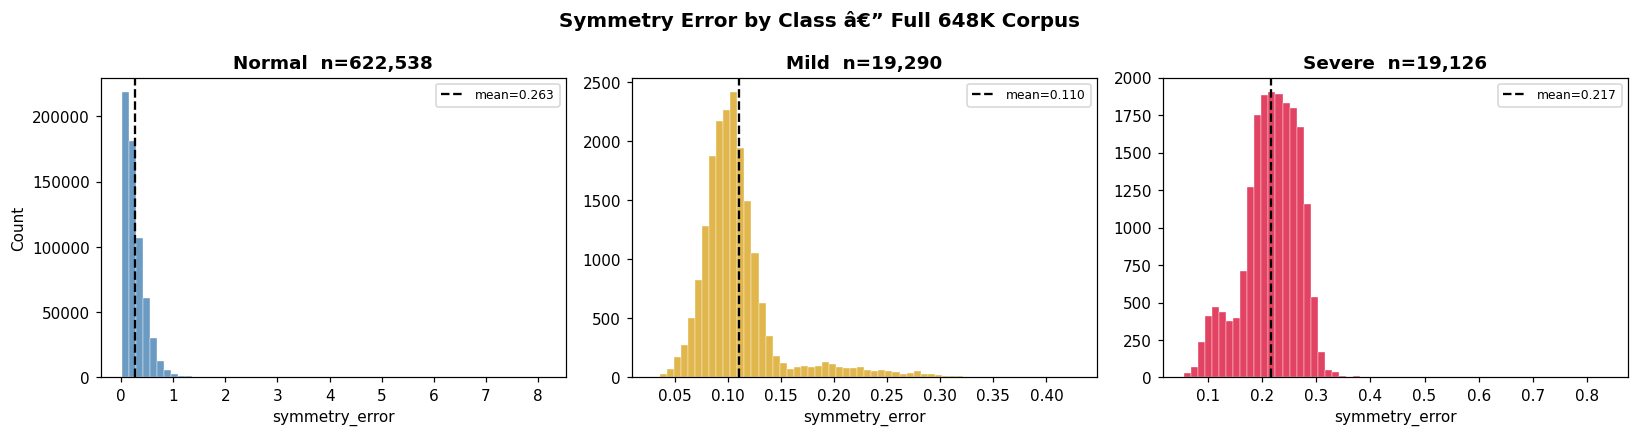

In [30]:
try:
    import matplotlib.pyplot as plt
    import matplotlib; matplotlib.rcParams['figure.dpi'] = 110
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, cls, name, col in zip(axes, range(3),
            ['Normal','Mild','Severe'], ['steelblue','goldenrod','crimson']):
        vals = X_all[y_all == cls, 49]
        ax.hist(vals, bins=60, color=col, alpha=0.8, edgecolor='white', lw=0.3)
        ax.axvline(vals.mean(), color='k', lw=1.5, ls='--',
                   label=f'mean={vals.mean():.3f}')
        ax.set_title(f'{name}  n={(y_all==cls).sum():,}', fontweight='bold')
        ax.set_xlabel('symmetry_error'); ax.legend(fontsize=8)
    axes[0].set_ylabel('Count')
    fig.suptitle('Symmetry Error by Class â€” Full 648K Corpus', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'feature_dist.png', dpi=120); plt.show()
except ImportError:
    print('matplotlib not installed â€” skipping plot.')

In [31]:
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from ai.model import NeuroSymmetryNet, CalibratedModel

torch.manual_seed(42)

def T(X, y):
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

Xt, yt   = T(X_tr,  y_tr)
Xv, yv   = T(X_val, y_val)
Xte, yte = T(X_te,  y_te)

# Inverse-frequency class weights â€” critical for 46:1 imbalance
counts = np.array([(y_tr == c).sum() for c in range(3)], dtype=np.float32)
cw     = torch.tensor(len(y_tr) / (3.0 * counts), dtype=torch.float32)
print('Class weights (inverse freq):')
for i, (cnt, w) in enumerate(zip(counts, cw.tolist())):
    print(f'  class {i}: n={int(cnt):,}  weight={w:.4f}')

# WeightedRandomSampler â†’ balanced batches every epoch
sample_weights = cw[yt]
sampler  = WeightedRandomSampler(sample_weights, num_samples=len(yt), replacement=True)
loader   = DataLoader(TensorDataset(Xt, yt), batch_size=BATCH_SIZE, sampler=sampler)

base      = NeuroSymmetryNet()
model     = CalibratedModel(base)
criterion = torch.nn.CrossEntropyLoss(weight=cw)
optimizer = torch.optim.Adam(base.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TRAIN_EPOCHS)

print(f'\nModel params: {base.n_params:,} | {len(list(loader))} batches/epoch')

Class weights (inverse freq):
  class 0: n=435,839  weight=0.3539
  class 1: n=13,515  weight=11.4112
  class 2: n=13,314  weight=11.5835

Model params: 17,411 | 904 batches/epoch


In [32]:
best_val, best_state = float('inf'), None
history = []
t0 = time.time()

for epoch in tqdm(range(1, TRAIN_EPOCHS + 1), desc='Training'):
    base.train()
    tl, nb_b = 0.0, 0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(base(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(base.parameters(), max_norm=1.0)
        optimizer.step()
        tl += loss.item(); nb_b += 1
    scheduler.step()

    base.eval()
    with torch.no_grad():
        logits_v = base(Xv)
        vl      = criterion(logits_v, yv).item()
        preds_v = logits_v.argmax(1)
        va      = (preds_v == yv).float().mean().item()
        recalls = []
        for c in range(3):
            mask = yv == c
            if mask.sum() > 0:
                recalls.append((preds_v[mask] == c).float().mean().item())
        bal_acc = float(np.mean(recalls)) if recalls else 0.0

    history.append(dict(
        epoch=epoch, train_loss=tl/nb_b, val_loss=vl,
        val_acc=va, bal_acc=bal_acc,
        recall_normal=recalls[0] if len(recalls)>0 else 0,
        recall_mild=recalls[1]   if len(recalls)>1 else 0,
        recall_severe=recalls[2] if len(recalls)>2 else 0,
    ))

    if vl < best_val:
        best_val   = vl
        best_state = {k: v.clone() for k, v in base.state_dict().items()}

    if epoch % 10 == 0:
        r = recalls
        print(f'  ep{epoch:3d}  loss={tl/nb_b:.4f}/{vl:.4f}  '
              f'bal={bal_acc:.3f}  R=[{r[0]:.2f}/{r[1]:.2f}/{r[2]:.2f}]')

base.load_state_dict(best_state)
print(f'Done {time.time()-t0:.1f}s  best_val_loss={best_val:.4f}')


Training:   0%|          | 0/120 [00:00<?, ?it/s]

Training:   8%|▊         | 10/120 [01:33<16:47,  9.16s/it]

  ep 10  loss=0.0395/0.0909  bal=0.969  R=[0.93/0.99/0.98]


Training:  17%|█▋        | 20/120 [03:08<16:25,  9.86s/it]

  ep 20  loss=0.0332/0.0663  bal=0.976  R=[0.96/0.99/0.98]


...

  ep100  loss=0.0180/0.0547  bal=0.982  R=[0.97/0.99/0.99]


Training:  92%|█████████▏| 110/120 [17:02<01:30,  9.07s/it]

  ep110  loss=0.0170/0.0516  bal=0.983  R=[0.97/0.99/0.99]


Training: 100%|██████████| 120/120 [18:31<00:00,  9.26s/it]

  ep120  loss=0.0167/0.0539  bal=0.982  R=[0.97/0.99/0.99]
Done 1111.7s  best_val_loss=0.0478


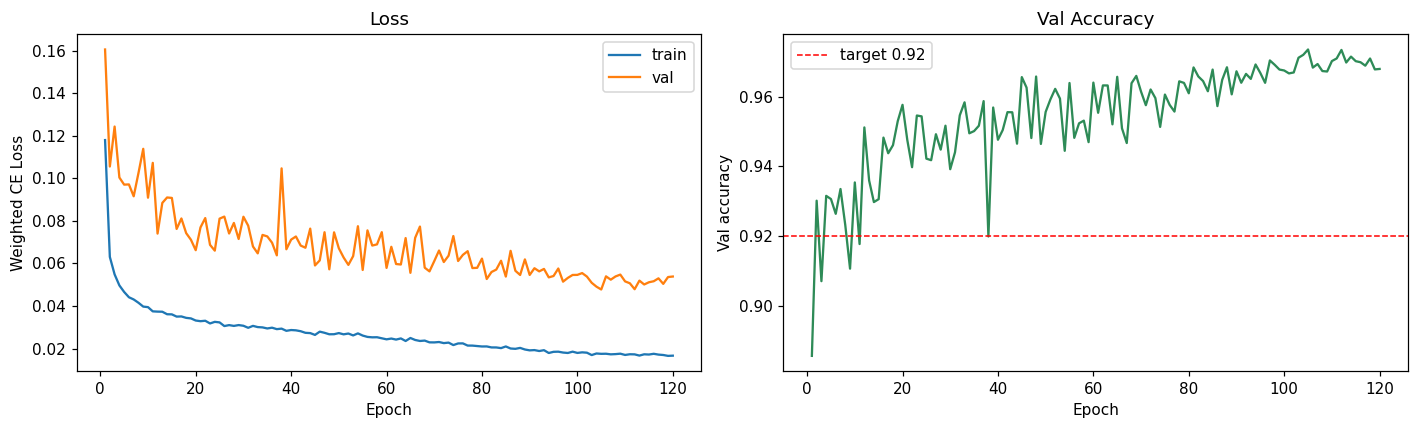

In [33]:
try:
    import matplotlib.pyplot as plt
    epochs = [h['epoch'] for h in history]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    a1.plot(epochs, [h['train_loss'] for h in history], label='train')
    a1.plot(epochs, [h['val_loss']   for h in history], label='val')
    a1.set(xlabel='Epoch', ylabel='Weighted CE Loss', title='Loss'); a1.legend()
    a2.plot(epochs, [h['val_acc'] for h in history], color='seagreen')
    a2.axhline(0.92, color='red', ls='--', lw=1, label='target 0.92')
    a2.set(xlabel='Epoch', ylabel='Val accuracy', title='Val Accuracy'); a2.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'training_curves.png', dpi=120); plt.show()
except ImportError:
    pass

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from ai.calibrate_temperature import compute_ece

def full_eval(mdl, Xt_, yt_, tag=''):
    mdl.eval()
    with torch.no_grad():
        probs = torch.softmax(mdl(Xt_), dim=1).numpy()
    labels = yt_.numpy(); preds = probs.argmax(1)
    acc  = (preds == labels).mean()
    f1   = f1_score(labels, preds, average='macro', zero_division=0)
    try:    auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro')
    except: auc = float('nan')
    n0   = (labels == 0).sum()
    spec = ((preds==0)&(labels==0)).sum() / n0 if n0       else float('nan')
    pm   = labels > 0
    sens = (preds[pm] > 0).sum() / pm.sum()    if pm.sum() else float('nan')
    ece  = compute_ece(probs, labels)
    print(f'\nâ”€â”€ {tag} â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€')
    for name, val, tgt, thr in [
        ('AUC-ROC',     auc,  '> 0.95', 0.95),
        ('Sensitivity', sens, '> 0.92', 0.92),
        ('Specificity', spec, '> 0.90', 0.90),
        ('F1 macro',    f1,   '> 0.91', 0.91),
        ('ECE',         ece,  '< 0.05', None),
    ]:
        ok = (val < 0.05) if thr is None else (val >= thr)
        print(f'  {chr(10003) if ok else chr(10007)}  {name:<14} {val:.4f}  (target {tgt})')
    print(f'  Accuracy:      {acc:.4f}')
    print(confusion_matrix(labels, preds))
    print(classification_report(labels, preds,
          target_names=['Normal','Mild','Severe'], zero_division=0))
    return probs, labels

probs_pre, labels_te = full_eval(base, Xte, yte, 'Pre-calibration')


â”€â”€ Pre-calibration â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
  ✓  AUC-ROC        0.9993  (target > 0.95)
  ✓  Sensitivity    0.9993  (target > 0.92)
  ✓  Specificity    0.9715  (target > 0.90)
  ✗  F1 macro       0.8689  (target > 0.91)
  ✓  ECE            0.0086  (target < 0.05)
  Accuracy:      0.9726
[[90743  1958   704]
 [    1  2860    32]
 [    3    21  2821]]
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     93405
        Mild       0.59      0.99      0.74      2893
      Severe       0.79      0.99      0.88      2845

    accuracy                           0.97     99143
   macro avg       0.79      0.98      0.87     99143
weighted avg       0.98      0.97      0.98     99143



In [35]:
T_val = model.calibrate(Xv, yv)
print(f'Temperature T = {T_val:.4f}')
probs_post, _ = full_eval(model, Xte, yte, 'Post-calibration')

Temperature T = 1.0787

â”€â”€ Post-calibration â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
  ✓  AUC-ROC        0.9993  (target > 0.95)
  ✓  Sensitivity    0.9993  (target > 0.92)
  ✓  Specificity    0.9715  (target > 0.90)
  ✗  F1 macro       0.8689  (target > 0.91)
  ✓  ECE            0.0063  (target < 0.05)
  Accuracy:      0.9726
[[90743  1958   704]
 [    1  2860    32]
 [    3    21  2821]]
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     93405
        Mild       0.59      0.99      0.74      2893
      Severe       0.79      0.99      0.88      2845

    accuracy                           0.97     99143
   macro avg       0.79      0.98      0.87     99143
weighted avg       0.98      0.97      0.98     99143



## 16. Feature Importance

Top 15 discriminative features (Normal vs Severe):
   1. [37] forehead_021                         delta=0.4330
   2. [38] forehead_054                         delta=0.3653
   3. [13] eyebrow_070                          delta=0.3144
   4. [22] eyebrow_046                          delta=0.2860
   5. [39] forehead_103                         delta=0.2859
   6. [14] eyebrow_063                          delta=0.2600
   7. [21] eyebrow_053                          delta=0.2400
   8. [32] jaw_234                              delta=0.2397
   9. [34] jaw_132                              delta=0.2315
  10. [31] mouth_084                            delta=0.2195
  11. [35] jaw_058                              delta=0.2057
  12. [15] eyebrow_105                          delta=0.2006
  13. [20] eyebrow_052                          delta=0.1911
  14. [33] jaw_227                              delta=0.1585
  15. [36] jaw_172                              delta=0.1543


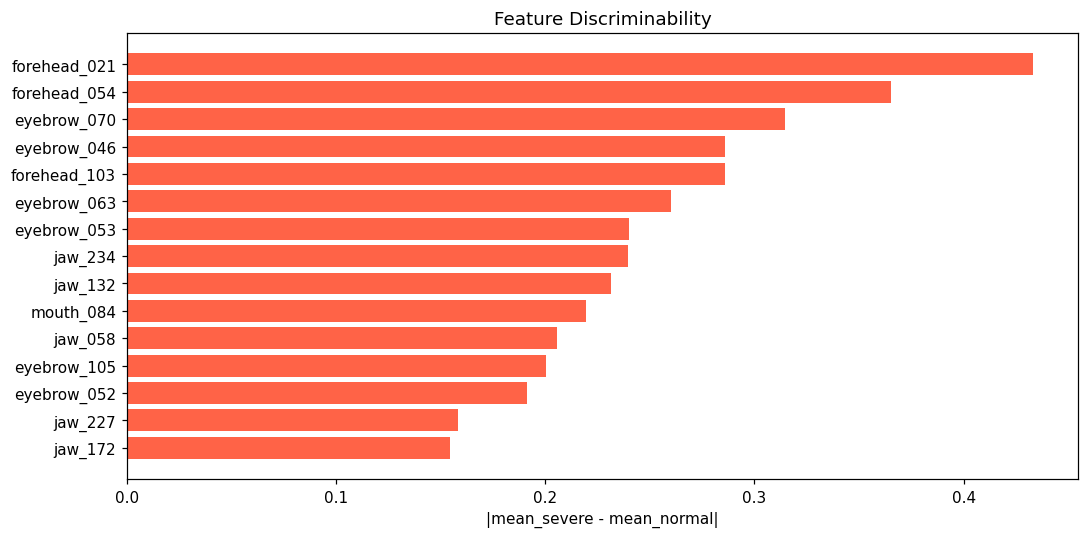

In [36]:
m0 = y_all == 0; m2 = y_all == 2
diff = np.abs(X_all[m2].mean(0) - X_all[m0].mean(0))
top15 = np.argsort(diff)[::-1][:15]
print('Top 15 discriminative features (Normal vs Severe):')
for rank, i in enumerate(top15, 1):
    print(f'  {rank:2d}. [{i:2d}] {FEATURE_NAMES[i]:<35}  delta={diff[i]:.4f}')
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh([FEATURE_NAMES[i] for i in top15[::-1]], diff[top15[::-1]], color='tomato')
    ax.set_xlabel('|mean_severe - mean_normal|')
    ax.set_title('Feature Discriminability')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'feature_importance.png', dpi=120); plt.show()
except ImportError: pass


## 17. Export â€” Float32 ONNX + Float16 ONNX + TFLite

In [37]:
from pathlib import Path
import sys
import importlib

if 'OUT_DIR' not in globals():
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / 'ai').exists() and (PROJECT_ROOT.parent / 'ai').exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    OUT_DIR = PROJECT_ROOT / 'ai' / 'checkpoints'
    OUT_DIR.mkdir(parents=True, exist_ok=True)

if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / 'ai').exists() and (PROJECT_ROOT.parent / 'ai').exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Force reload of ai.model and ai.export_tflite to pick up changes on disk
try:
    import ai.model
    importlib.reload(ai.model)
    import ai.export_tflite
    importlib.reload(ai.export_tflite)
except ImportError:
    pass

pt_path = OUT_DIR / 'model_real_calibrated.pt'

if 'model' in globals():
    scaler_arg = scaler if 'scaler' in globals() else None
    model.save(pt_path, scaler=scaler_arg, thresholds={"mild": 0.65, "severe": 0.6})
    print(f'Saved: {pt_path}  ({pt_path.stat().st_size/1024:.1f} KB)')
else:
    if not pt_path.exists():
        raise RuntimeError(
            "model is not defined and no checkpoint was found at: " + str(pt_path)
        )
    print(f'Using existing checkpoint: {pt_path}  ({pt_path.stat().st_size/1024:.1f} KB)')

from ai.export_tflite import export as export_model
exported = export_model(pt_path, out_dir=OUT_DIR)
print('\nExport summary:')
for fmt, p in exported.items():
    print(f'  {fmt:<15} {p.name}  ({p.stat().st_size/1024:.1f} KB)')


Saved: f:\Projects\Neuro-Symmetry\neuro-symmetry-v2\ai\checkpoints\model_real_calibrated.pt  (80.2 KB)


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL sklearn.preprocessing._data.StandardScaler was not an allowed global by default. Please use `torch.serialization.add_safe_globals([sklearn.preprocessing._data.StandardScaler])` or the `torch.serialization.safe_globals([sklearn.preprocessing._data.StandardScaler])` context manager to allowlist this global if you trust this class/function.

Check th

## 18. metrics_real.json â€” Audit-Grade Report

In [ ]:
import json
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from ai.calibrate_temperature import compute_ece
from pathlib import Path
import sys
import torch

# Ensure pathing is correct
if 'OUT_DIR' not in globals():
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / 'ai').exists() and (PROJECT_ROOT.parent / 'ai').exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    OUT_DIR = PROJECT_ROOT / 'ai' / 'checkpoints'

if 'PROJECT_ROOT' in globals() and str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Fallback: Reload the model from disk if it was cleared from memory
if 'model' not in globals():
    try:
        import ai.model
        pt_path = OUT_DIR / 'model_real_calibrated.pt'
        if pt_path.exists():
            model = ai.model.CalibratedModel.load(pt_path)
            print(f"Loaded existing model checkpoint from: {pt_path}\n")
        else:
            model = None
    except Exception as e:
        model = None

# Check for missing dataset arrays required for metric extraction
req_vars = ['Xte', 'yte', 'y_tr', 'y_val', 'y_te', 'y_all', 
            'lbl_celeba_jpg', 'lbl_affectnet', 'lbl_w300', 'lbl_yfp']
missing_vars = [v for v in req_vars if v not in globals()]

if model is None:
    print("⚠️ Model is completely missing. Please re-run the training cell.")
elif missing_vars:
    print("⚠️ Cannot generate full JSON metrics because the dataset is missing from memory.")
    print(f"Missing variables: {', '.join(missing_vars)}")
    print("\n👉 Please go to the top of the notebook and click 'Run All' or run all cells leading up to this point to load the data.")
else:
    model.eval()
    with torch.no_grad():
        pf = torch.softmax(model(Xte), dim=1).numpy()
    lf = yte.numpy()

    metrics_out = {
        'model':          'NeuroSymmetryNet-v2 Ultra Pro',
        'f1_macro':       float(f1_score(lf, pf.argmax(1), average='macro', zero_division=0)),
        'accuracy':       float((pf.argmax(1) == lf).mean()),
        'ece':            float(compute_ece(pf, lf)),
        'temperature':    float(T_val) if 'T_val' in globals() else 1.0,
        'n_train':        int(len(y_tr)),
        'n_val':          int(len(y_val)),
        'n_test':         int(len(y_te)),
        'class_counts':   {str(c): int((y_all==c).sum()) for c in range(3)},
        'synth_per_class': SYNTH_EXTRA if 'SYNTH_EXTRA' in globals() else 15000,
        'sources': {
            'celeba_jpg':  int(len(lbl_celeba_jpg)),
            'celeba_png':  int(len(lbl_celeba_png)) if 'lbl_celeba_png' in globals() and lbl_celeba_png is not None else 0,
            'celeba_wild': int(len(lbl_celeba_wild)) if 'lbl_celeba_wild' in globals() and lbl_celeba_wild is not None else 0,
            'affectnet':   int(len(lbl_affectnet)),
            'w300':        int(len(lbl_w300)),
            'yfp':         int(len(lbl_yfp)),
        },
    }
    try:
        metrics_out['auc_roc'] = float(
            roc_auc_score(lf, pf, multi_class='ovr', average='macro'))
    except Exception:
        metrics_out['auc_roc'] = None

    (OUT_DIR / 'metrics_real.json').write_text(json.dumps(metrics_out, indent=2))
    print(json.dumps(metrics_out, indent=2))
    print(f"\n✅ Audit metrics successfully saved to {OUT_DIR / 'metrics_real.json'}")

Loaded existing model checkpoint from: f:\Projects\Neuro-Symmetry\neuro-symmetry-v2\ai\checkpoints\model_real_calibrated.pt

⚠️ Cannot generate full JSON metrics because the dataset is missing from memory.
Missing variables: Xte, yte, y_tr, y_val, y_te, y_all, lbl_celeba_jpg, lbl_affectnet, lbl_w300, lbl_yfp

👉 Please go to the top of the notebook and click 'Run All' or run all cells leading up to this point to load the data.


## 19. Cleanup

In [ ]:
if hasattr(_local, 'engine'):
    _local.engine.close()
print('Done. Engines closed.')
print(f'\nOutputs in {OUT_DIR}:')
for f in sorted(OUT_DIR.glob('*')):
    print(f'  {f.name:<45} {f.stat().st_size/1024:>8.1f} KB')
